In [1]:
from dataclasses import replace, dataclass
from typing import List, Tuple
import pandas as pds
from typing import Literal, Optional 
import pandas as pd 

from src.dataloading.epidataorchestration import EpiConfig, EpiDataOrchestrator

Entire regimen we've been studying is:

min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'

Fixed origin expanding window:
splits = [
    ('2011-06-01', '2014-06-01', '2015-06-01', '2016-06-01'),
    ('2011-06-01', '2015-06-01', '2016-06-01', '2017-06-01'),
    ('2011-06-01', '2016-06-01', '2017-06-01', '2018-06-01'),
    ('2011-06-01', '2017-06-01', '2018-06-01', '2019-06-01'),
    ('2011-06-01', '2018-06-01', '2019-06-01', '2020-06-01'),
]

Expanding window:
splits = [
    ('2011-06-01', '2014-06-01', '2015-06-01', '2016-06-01'),
    ('2012-06-01', '2015-06-01', '2016-06-01', '2017-06-01'),
    ('2013-06-01', '2016-06-01', '2017-06-01', '2018-06-01'),
    ('2014-06-01', '2017-06-01', '2018-06-01', '2019-06-01'),
    ('2015-06-01', '2018-06-01', '2019-06-01', '2020-06-01'),
]

In [2]:
from tqdm import tqdm

from src.dataloading import EpiConfig, EpiDataOrchestrator

from src.dataloading import BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel

from dataclasses import dataclass, field
from typing import Literal, assert_never, Dict
import pandas as pd

from src.issues import Error
from src.utils import align

class CrossValidationEpiConfigError(Error):
    """
    errors are to be raised!
    """    
    def __init__(self, message: str, *, code: str | None = None, context: str | None = None):
        super().__init__(message, code=code, context=context)

@dataclass(frozen=True)
class CrossValidationEpiConfig:
    """ 
    One collection of multiple EpiConfigs: 1 per fold

    Parameters
    ----------
    min_date:   str
        first date to be included 
    max_date:   str
        final date to be included
    num_folds : int
        Number of folds to generate.
    train_periods : int
        Length of training window in `unit` units.
    val_periods : int
        Length of validation window in `unit` units.
    test_periods : int
        Length of test window in `unit` units.
    expansion_method : Literal['fixed_origin', 'rolling_window']
        fixed_origin: training always starts at min_date, grows each fold.
        rolling_window: training window slides forward each fold.
    unit : Literal['years', 'months']
        Temporal unit for all period lengths and rolling offsets.
        Use 'years' for influenza (weekly data).
        Use 'months' for COVID (daily data).

    Examples
    --------
    ### Influenza — yearly splits
    >>> cfg = CrossValidationEpiConfig(
            min_date='2011-06-01', max_date='2020-06-01',
            num_folds=5, train_periods=3, val_periods=1, test_periods=1,
            method='rolling_window', unit='years'
    )

    ### COVID — monthly splits
    >>> cfg = CrossValidationEpiConfig(
            min_date='2020-03-02', max_date='2023-01-01',
            num_folds=5, train_periods=12, val_periods=3, test_periods=3,
            method='rolling_window', unit='months'
    )        
    """
    min_date        : str
    max_date        : str
    num_folds       : int
    fold_step       : int
    train_periods   : int
    val_periods     : int
    test_periods    : int
    expansion_method: Literal['fixed_origin', 'rolling_window'] = 'rolling_window'
    unit            : Literal['y','m','w','d']   = 'y'

    _splits         : Dict[int, Dict[str,str]] = field(default_factory=dict, init=False, repr=False)

    # ======== DUNDER ======== #
    def __post_init__(self):
        self._validate_input()
        self._validate_time()
        self._set_splits()

    def __len__(self) -> int:
        return self.num_folds

    def __iter__(self):
        for i in range(self.num_folds):
            yield self._splits[i]

    def __getitem__(self, fold_idx: int):
        return self._splits[fold_idx]

    # ======= METHODS ======== #
    def get_all_splits(self) -> Dict[int, Dict[str, str]]:
        return dict(self._splits)

    # ======== HELPERS ========= #    
    def _set_splits(self):
        """set split - info in `.splits_`"""
        min_dt = pd.Timestamp(self.min_date)
        max_dt = pd.Timestamp(self.max_date)

        for fold_idx in range(self.num_folds):

            if self.expansion_method == 'fixed_origin':
                train_start = min_dt
                train_end   = min_dt + self._offset(self.train_periods + fold_idx * self.fold_step)
            elif self.expansion_method == 'rolling_window':
                train_start = min_dt + self._offset(fold_idx * self.fold_step)
                train_end   = train_start + self._offset(self.train_periods)

            else:
                assert_never(self.expansion_method)

            fold_min_date       = train_start
            fold_trainval_split = train_end
            fold_valtest_split  = train_end + self._offset(self.val_periods)
            fold_max_date       = fold_valtest_split + self._offset(self.test_periods)

            if fold_max_date > max_dt:
                raise ValueError(
                    f"Fold {fold_idx} exceeds max_date. Reduce num_folds."
                )

            self._splits[fold_idx] = {
                'min_date'       : fold_min_date.strftime('%Y-%m-%d'),
                'trainval_split' : fold_trainval_split.strftime('%Y-%m-%d'),
                'valtest_split'  : fold_valtest_split.strftime('%Y-%m-%d'),
                'max_date'       : fold_max_date.strftime('%Y-%m-%d'),
            }
    
    def _offset(self, n: int) -> pd.DateOffset:
        """Return a DateOffset of n units."""
        match self.unit:
            case "y":
                return pd.DateOffset(years=n)
            case "m":
                return pd.DateOffset(months=n)  
            case "w":
                return pd.DateOffset(weeks=n)
            case "d":
                return pd.DateOffset(days=n)
            case _:
                assert_never(self.unit)        

    # ======= VALIDATION ========= #
    def _validate_input(self):
        """validate restricted inputs"""
        allowed_units = ['y','m','w','d']
        if self.unit not in allowed_units:
            raise CrossValidationEpiConfigError(f'Invalid input for unit. Must be one of {allowed_units}. Got {self.unit}')
        
        allowed_methods = ['rolling_window','fixed_origin']
        if self.expansion_method not in allowed_methods:
            raise CrossValidationEpiConfigError(f'Invalid input for expansion_method. Must be one of {allowed_methods}. Got {self.expansion_method}')        

        if self.fold_step < 1:
            raise CrossValidationEpiConfigError(
                f'fold_step must be >= 1. Got {self.fold_step}'
            )            
        
    def _validate_time(self):
        """validate input of temporal nature"""
        min_dt = pd.Timestamp(self.min_date)
        max_dt = pd.Timestamp(self.max_date)

        # Check a single fold fits within the date range
        single_fold_end = (
            min_dt
            + self._offset(self.train_periods)
            + self._offset(self.val_periods)
            + self._offset(self.test_periods)
        )
        if single_fold_end > max_dt:
            raise CrossValidationEpiConfigError(
                f"Date range {self.min_date} to {self.max_date} is too short "
                f"for train/val/test = "
                f"{self.train_periods}/{self.val_periods}/{self.test_periods} {self.unit}."
            )

        if self.expansion_method == 'fixed_origin':
            last_test_end = (
                min_dt
                + self._offset(self.train_periods + (self.num_folds - 1) * self.fold_step)
                + self._offset(self.val_periods)
                + self._offset(self.test_periods)
            )
        elif self.expansion_method == 'rolling_window':
            last_test_end = (
                min_dt
                + self._offset((self.num_folds - 1) * self.fold_step)
                + self._offset(self.train_periods)
                + self._offset(self.val_periods)
                + self._offset(self.test_periods)
            )
        else:
            assert_never(self.expansion_method)

        if last_test_end > max_dt:
            raise CrossValidationEpiConfigError(
                f"{self.num_folds} folds with these window sizes exceed the available "
                f"date range. Last fold would end {last_test_end.date()}, "
                f"but max_date is {self.max_date}."
            )    

    # ======= REPRESENTATION ====== #
    def summary(self) -> str:
        alignment = "^"
        column_sizes = [6, 14, 14, 14, 14]

        # Header
        header = (
            f"{'Fold':{alignment}{column_sizes[0]}} | "
            f"{'Min Date':{alignment}{column_sizes[1]}} | "
            f"{'Train/Val':{alignment}{column_sizes[2]}} | "
            f"{'Val/Test':{alignment}{column_sizes[3]}} | "
            f"{'Max Date':{alignment}{column_sizes[4]}}"
        )

        table_repr = [header]
        table_repr.append("-" * len(header))

        # Data rows
        for fold_idx, split_dict in self._splits.items():
            values = [fold_idx] + list(split_dict.values())
            line = " | ".join(
                f"{str(val):{alignment}{width}}" 
                for val, width in zip(values, column_sizes)
            )
            table_repr.append(line)

        table = "\n".join(table_repr)
        return table

    def __str__(self) -> str:
        return self.summary()

    def __repr__(self) -> str:
        """returns aligned repr of input"""
        all_keys = ['num_folds','fold_step','train_periods','val_periods','test_periods','unit','expansion_method']

        width           = max(len(k) for k in all_keys)
        indent          = 4

        lines = [f"<{self.__class__.__name__}(\n"]

        for attr_name in all_keys:
            attr_value = getattr(self, attr_name)
            lines.append(align(attr_name, attr_value, width, indent = indent, newline = True))

        lines.append(")>")
        representation = "".join(lines)
        return representation

@dataclass
class EpiFold:
    fold_idx:   int
    metadata:   Dict[str, str] 
    epiconfig:  EpiConfig
    data_orch:  EpiDataOrchestrator

    def __repr__(self) -> str:
        representation = f"<{self.__class__.__name__}(fold_idx = {self.fold_idx}, metadata, epiconfig, data_orch)>"

        return representation
    
@dataclass
class FoldCollection:
    epifolds:   List[EpiFold]
    foldconfig: CrossValidationEpiConfig

    @classmethod
    def build(cls, cv_config: CrossValidationEpiConfig, 
            base_config: EpiConfig) -> 'FoldCollection':
        
        # ── Step 1: run the expensive part once ──────────────────────────
        global_orch = EpiDataOrchestrator(base_config)
        global_orch.load_raw()
        shared_raw = global_orch.data_raw  # RawEpiData — just dataframes, fully shareable


        # ── Step 2: cheap per-fold pipeline ──────────────────────────────
        folds = []
        for fold_idx in tqdm(range(cv_config.num_folds)):
            split = cv_config[fold_idx]

            fold_config = replace(
                base_config,
                min_date       = split['min_date'],
                split_trainval = split['trainval_split'],
                split_valtest  = split['valtest_split'],
                max_date       = split['max_date'],
            )

            fold_orch = (
                EpiDataOrchestrator.from_raw(fold_config, shared_raw)
                .harmonize_raw()
                .process_data()
                .build_features()
                .normalize()
                .finalize()
            )
            
            folds.append(EpiFold(
                fold_idx  = fold_idx,
                metadata  = split,
                epiconfig = fold_config,
                data_orch = fold_orch,
            ))
        
        return cls(epifolds=folds, foldconfig=cv_config)

    def __iter__(self):
        return iter(self.epifolds)
    
    def __len__(self):
        return len(self.epifolds)
    
    def __getitem__(self, fold_idx: int):
        return self.epifolds[fold_idx]
    
    def summary(self) -> str:
        lines = [self.foldconfig.summary(), ""]
        for fold in self.epifolds:
            lines.append(repr(fold))
        return "\n".join(lines)

In [3]:
cv_config = CrossValidationEpiConfig(
    min_date            = '2011-06-01',
    max_date            = '2024-06-01',
    num_folds           = 9,
    fold_step           = 1,
    train_periods       = 3,
    val_periods         = 1,
    test_periods        = 1,
    expansion_method    = 'rolling_window',
    unit                = 'y'
)


In [4]:
print(cv_config)

 Fold  |    Min Date    |   Train/Val    |    Val/Test    |    Max Date   
--------------------------------------------------------------------------
  0    |   2011-06-01   |   2014-06-01   |   2015-06-01   |   2016-06-01  
  1    |   2012-06-01   |   2015-06-01   |   2016-06-01   |   2017-06-01  
  2    |   2013-06-01   |   2016-06-01   |   2017-06-01   |   2018-06-01  
  3    |   2014-06-01   |   2017-06-01   |   2018-06-01   |   2019-06-01  
  4    |   2015-06-01   |   2018-06-01   |   2019-06-01   |   2020-06-01  
  5    |   2016-06-01   |   2019-06-01   |   2020-06-01   |   2021-06-01  
  6    |   2017-06-01   |   2020-06-01   |   2021-06-01   |   2022-06-01  
  7    |   2018-06-01   |   2021-06-01   |   2022-06-01   |   2023-06-01  
  8    |   2019-06-01   |   2022-06-01   |   2023-06-01   |   2024-06-01  


In [5]:
global_epiconfig = EpiConfig.load_config('default_influenza_point_prediction')
global_epiconfig.feature_gisd = False
global_epiconfig.time_index_w = False

fold_collection = FoldCollection.build(cv_config, global_epiconfig)

EpiConfig default_influenza_point_prediction loaded


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:03<00:00,  2.31it/s]


In [6]:
models = {}

for fold_idx, fold in enumerate(fold_collection):

    baseline_data            = BaseLineDataLoaderManager(fold.data_orch)
    
    # constant_predictor      = ConstantModel(baseline_data,name      = f'fold{fold_idx+1}')
    persistence_predictor   = PersistenceModel(baseline_data,name   = f'fold{fold_idx+1}')
    climateology            = ClimateologyModel(baseline_data,name  = f'fold{fold_idx+1}')
    # climascale              = ClimaScaleModel(baseline_data,name    = f'fold{fold_idx+1}')

    # constant_predictor.set_model_hparams(0)

    for ml in [persistence_predictor, climateology]:
        ml.train()
    
    # constant_predictor.forecast('test')
    persistence_predictor.forecast('test')
    climateology.forecast('test')
    # climascale.forecast('test')

    models_fold = [persistence_predictor,climateology]
    models[f'fold{fold_idx+1}'] = models_fold

In [ ]:
# model_evaluations_foldwise 
from src.evaluation import Evaluator

persistences    = []
climateologies  = []


for fold_idx, fold in enumerate(fold_collection):
    for model_idx, model in enumerate(models[f'fold{fold_idx + 1}']):
        if model.__class__.__name__ == 'PersistenceModel':
            persistences.append(model)
        if model.__class__.__name__ == 'ClimateologyModel':
            climateologies.append(model)


evaluators = {
    'persistence':  Evaluator(persistences).add_evaluation(),
    'climateology': Evaluator(climateologies).add_evaluation()
}

figure_raw1 = (evaluators['persistence'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'persistence', fontweight='bold', fontsize=14)
            )



figure_raw2 = (evaluators['climateology'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'climateology', fontweight='bold', fontsize=14)
            )


  0%|                                                                                                                                                                                | 0/3600 [00:00<?, ?it/s]

  2%|██▉                                                                                                                                                                   | 65/3600 [00:00<00:05, 647.02it/s]

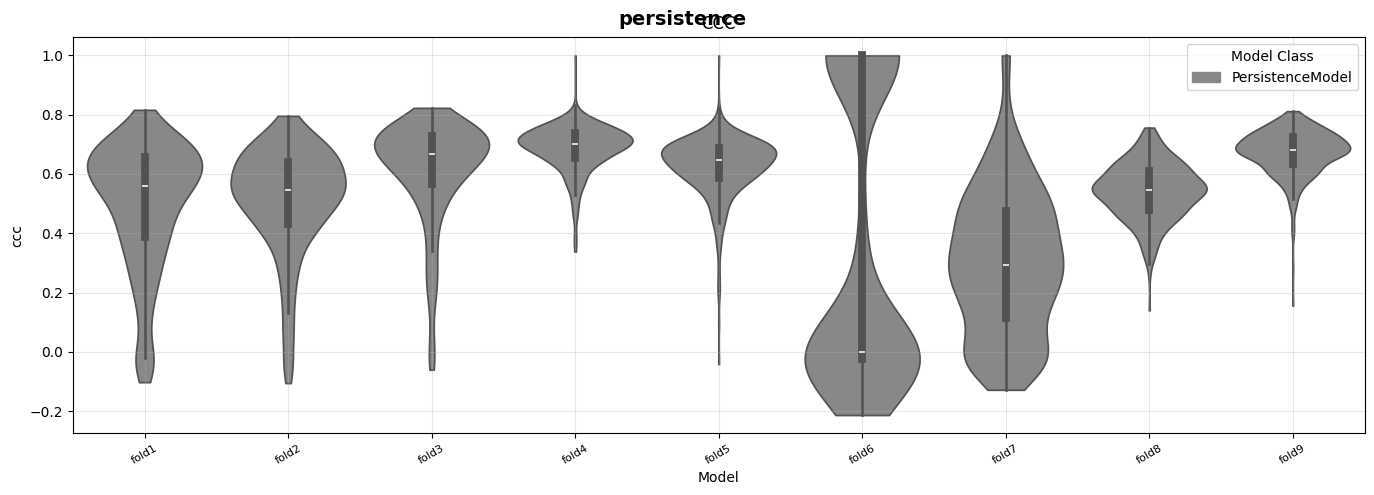

In [ ]:
figure_raw1.show()


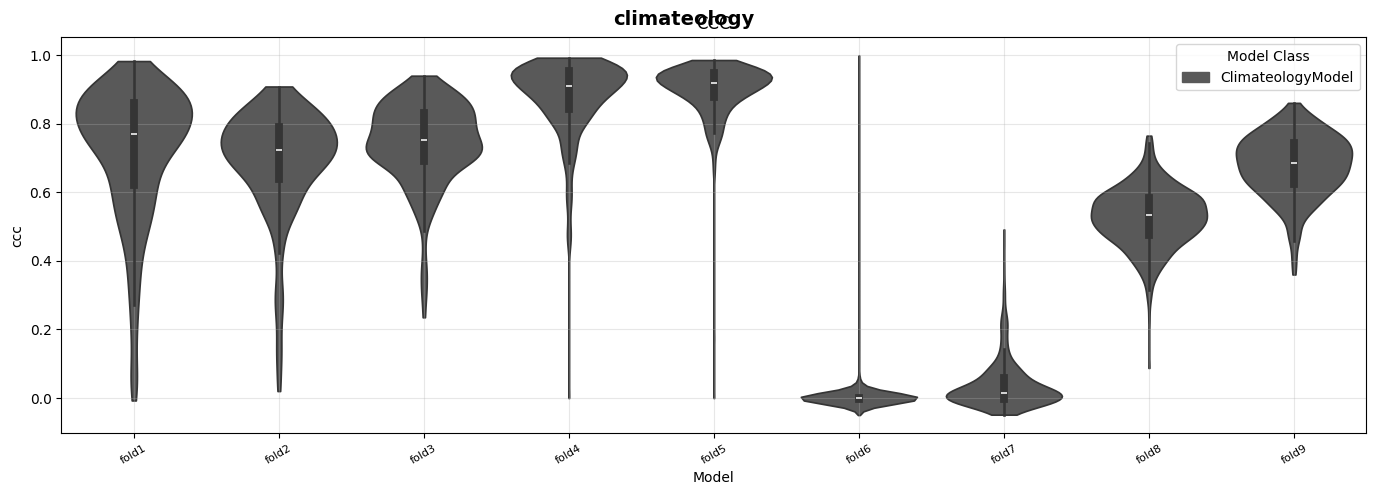

In [ ]:
figure_raw2.show()

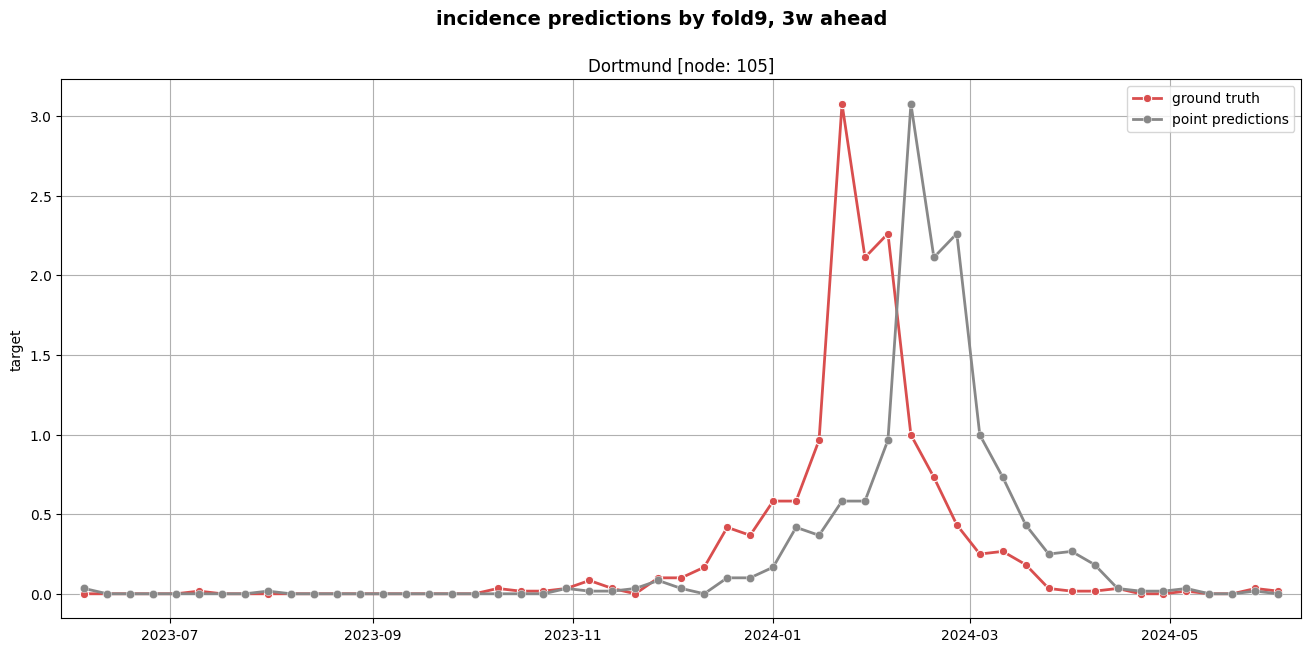

In [ ]:
persistences[8].show_forecasts(105).show()

In [ ]:
from src.models import GCNLSTMModel
from src.dataloading import GraphDataLoaderManager

n_epochs        = 500
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

deepmodels = {}

for fold_idx, fold in enumerate(fold_collection):

    graphloader1            = GraphDataLoaderManager(fold.data_orch).retrieve_static_graph('identity_graph').build()
    graphloader2            = GraphDataLoaderManager(fold.data_orch).retrieve_static_graph('geographical_neighbors1').build()

    # constant_predictor      = ConstantModel(baseline_data,name      = f'fold{fold_idx+1}')
    gatv1   = GCNLSTMModel(graphloader1,name   = f'ig_fold{fold_idx+1}')
    gatv2   = GCNLSTMModel(graphloader2,name   = f'gn_fold{fold_idx+1}')
    # climascale              = ClimaScaleModel(baseline_data,name    = f'fold{fold_idx+1}')

    # constant_predictor.set_model_hparams(0)

    for ml in [gatv1, gatv2]:
        ml.set_model_hparams()
        ml.set_global_hparams(**global_hparams)
        ml.train()
        ml.forecast()


    models_fold = [gatv1,gatv2]
    models[f'fold{fold_idx+1}'] = models_fold

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 1.0764
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 1.0816
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3990
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4291
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.8517
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.8260
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 1.1032
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 1.1287
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.2352
E

In [ ]:
# model_evaluations_foldwise 
from src.evaluation import Evaluator

igs    = []
gns  = []


for fold_idx, fold in enumerate(fold_collection):
    for model_idx, model in enumerate(models[f'fold{fold_idx + 1}']):
        if 'ig_fold' in model.name:
            igs.append(model)
        if 'gn_fold' in model.name:
            gns.append(model)

evaluators = {
    'ig':  Evaluator(igs).add_evaluation(),
    'gn': Evaluator(gns).add_evaluation()
}

figure_raw1 = (evaluators['ig'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'identity graph', fontweight='bold', fontsize=14)
            )



figure_raw2 = (evaluators['gn'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'geographical neighbors', fontweight='bold', fontsize=14)
            )


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3600/3600 [00:04<00:00, 837.28it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


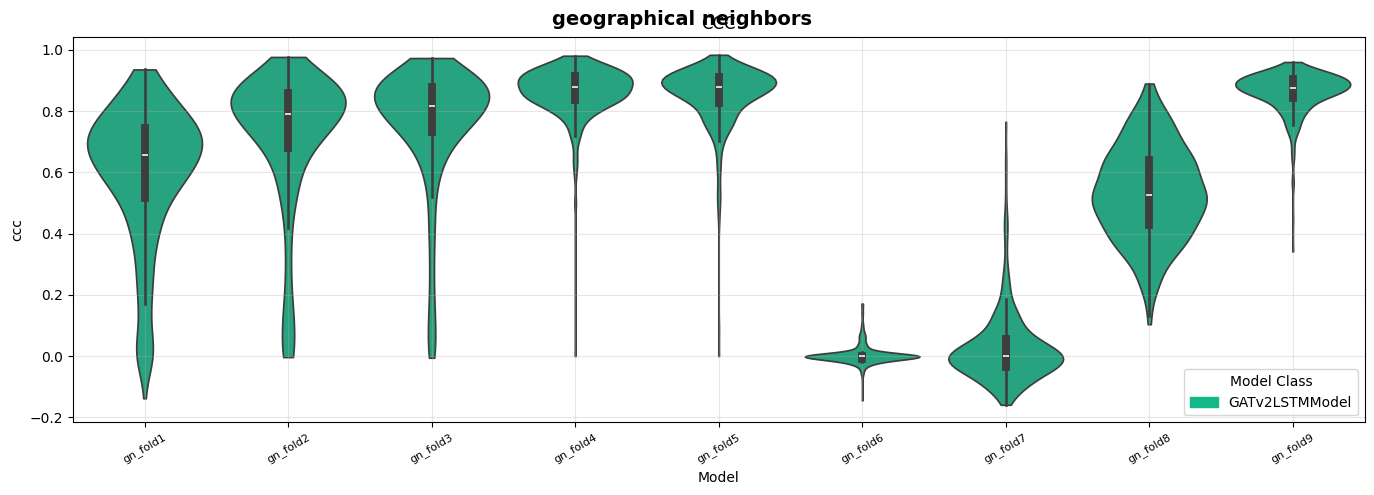

In [ ]:
figure_raw2.show()

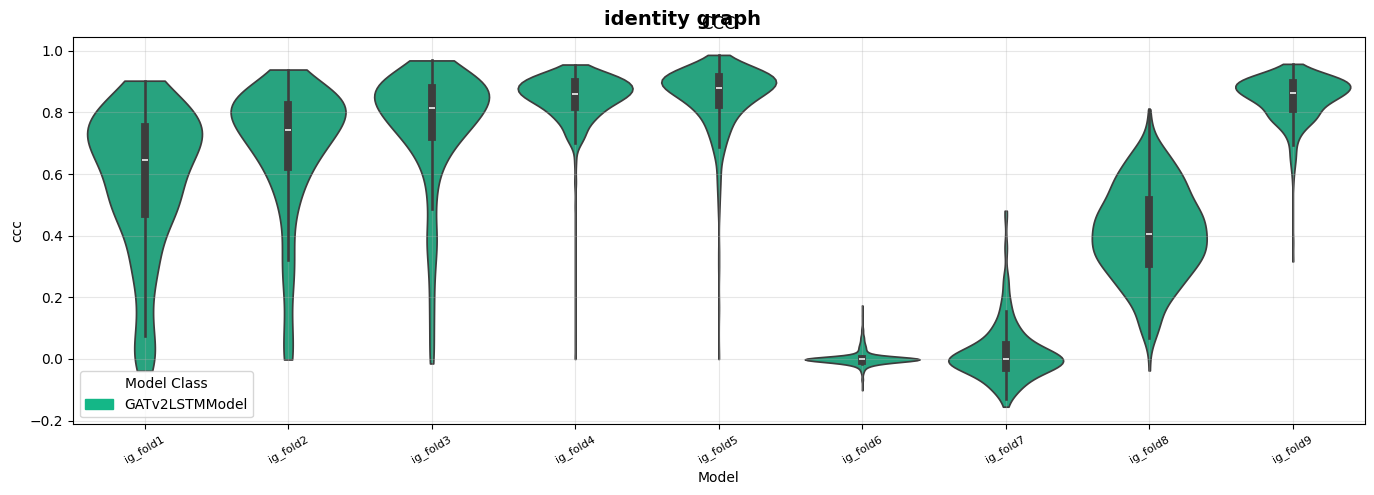

In [ ]:
figure_raw1.show()

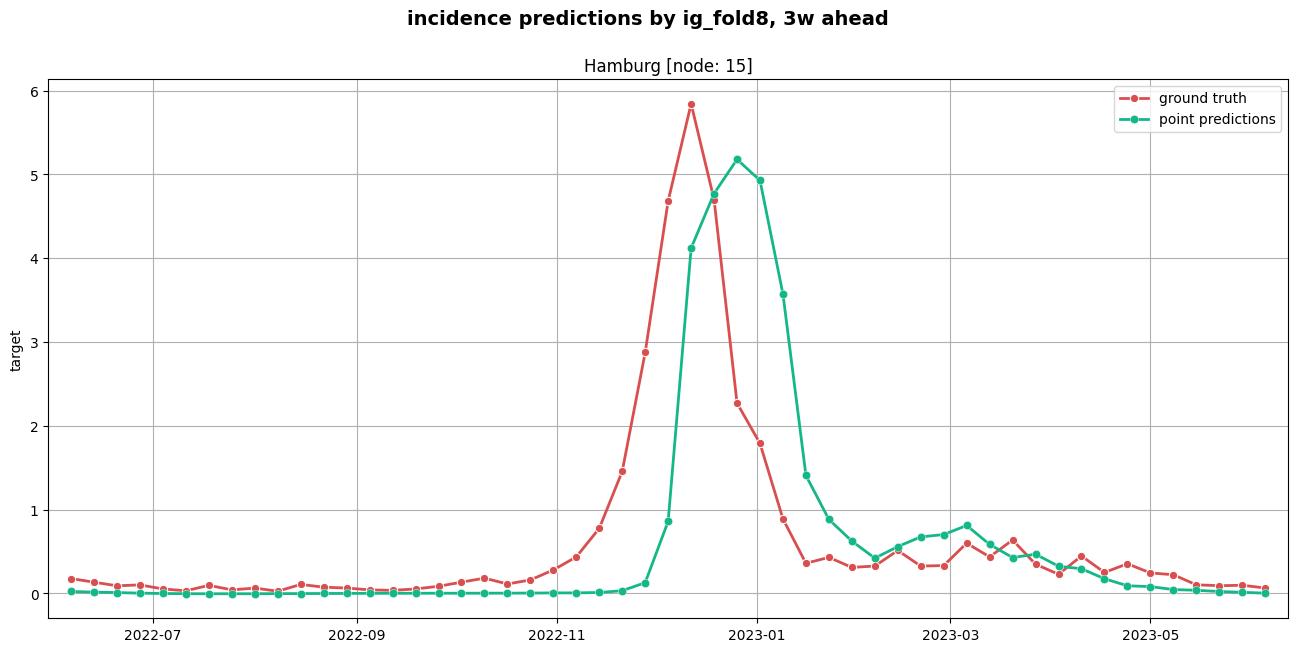

In [ ]:
igs[7].show_forecasts(15).show()

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


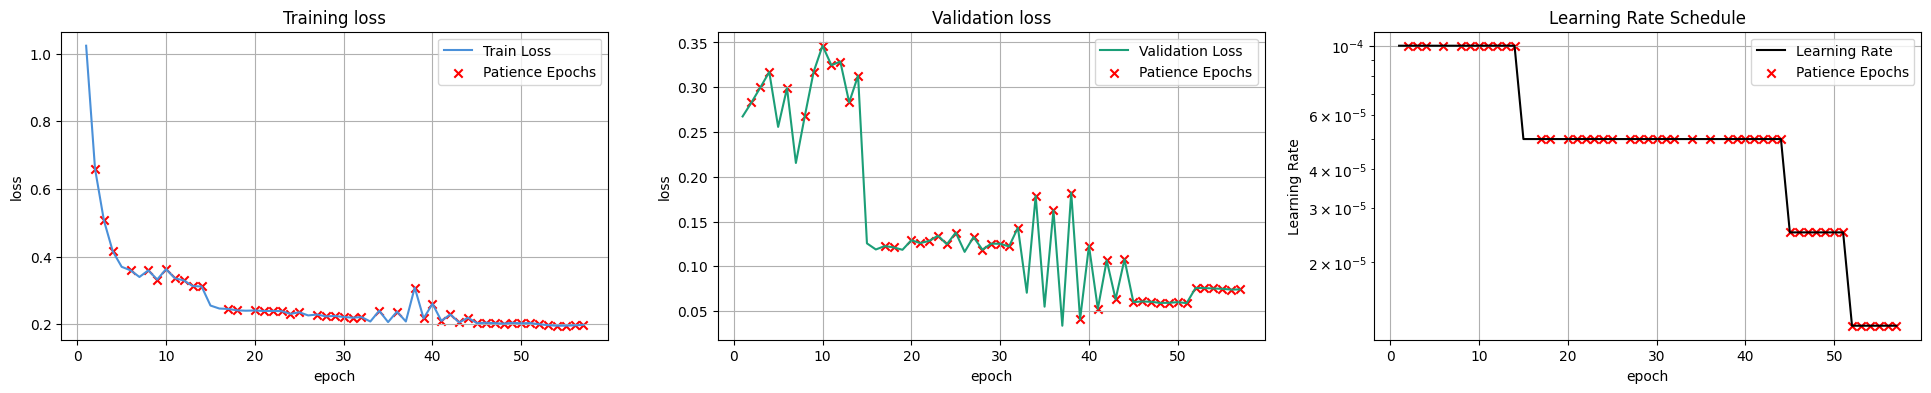

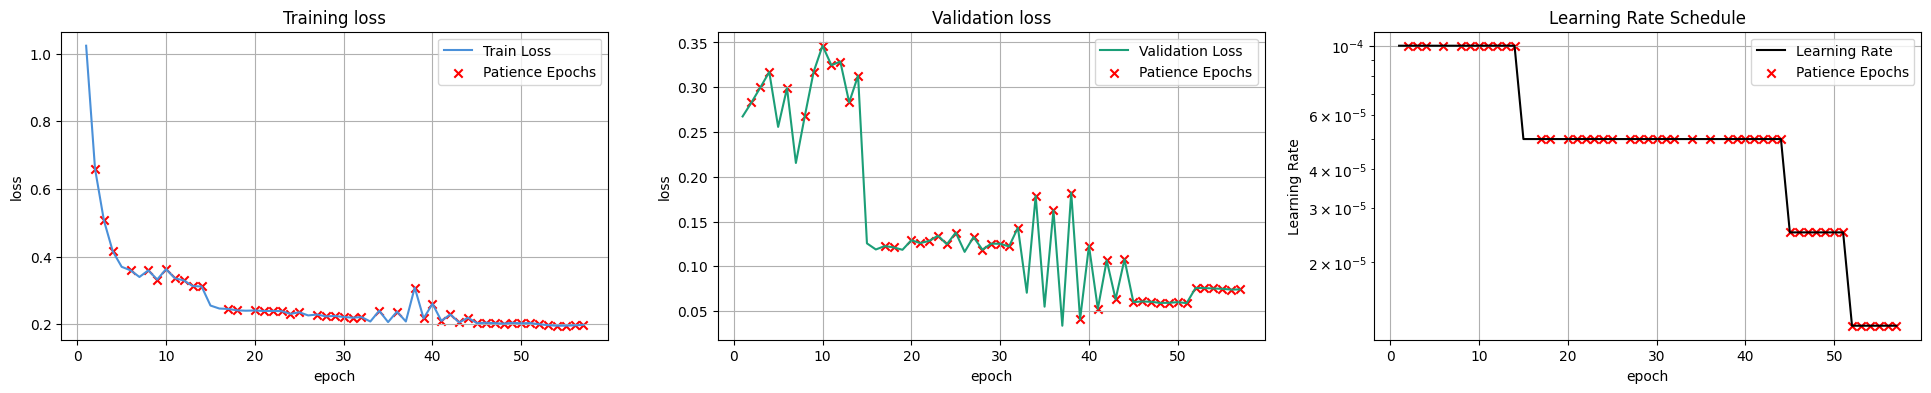

In [ ]:
gns[6].show_monitoring_metrics()